In [ ]:
import numpy as np
import pandas as pd

In [ ]:
courses=pd.read_csv('/content/courses.csv')
matches=pd.read_csv('/content/matches.csv')
nov=pd.read_csv('/content/reg-month1.csv')
dec=pd.read_csv('/content/reg-month2.csv')
students=pd.read_csv('/content/students.csv')
delivery=pd.read_csv('/content/deliveries.csv')

In [ ]:
nov.shape

(25, 2)

In [ ]:
# pd.concat :- do ko jorane ke liye
# isme index retain kr liya h
# ignore_index=True se purana index retain nhi hota h
regs=pd.concat([nov,dec],ignore_index=True)
# purane ko rakhane ke baad
multi=pd.concat([nov,dec],keys=['Nov','Dec'])
multi

student_id  course_id
Nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
Dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [ ]:
multi.loc[('Dec',4)]

,Dec
,4
student_id,14
course_id,9


In [ ]:
pd.concat([nov,dec],axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [ ]:
# inner join:- common part hi aaiga
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [ ]:
# left join:-left waale table ka saare aaiga
courses.merge(regs,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [ ]:
# right join :- jo right me h woo sab aaiga
# just in how we have to write right

In [ ]:
# outer join
courses.merge(regs,how='outer',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [ ]:
# find the total revenue generated by the company
regs.merge(courses,how='inner',on='course_id')['price'].sum()

np.int64(154247)

In [ ]:
# find month by month revenue
temp=pd.concat([nov,dec],keys=['Nov','Dec']).reset_index()
temp.merge(courses,on='course_id').groupby('level_0')['price'].sum()

,price
level_0,
Dec,65072
Nov,89175


In [ ]:
# print the registration table
regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

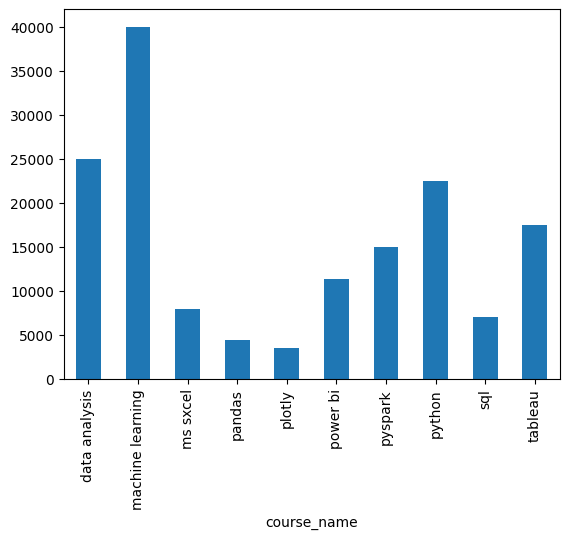

In [ ]:
# plot a bar chart for revenue/couses
regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [ ]:
# find students who enrolled in both the months
common_student_id=np.intersect1d(nov['student_id'],dec['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [ ]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [ ]:
# find cousrse that got no enrollment
course_id_list=np.setdiff1d(courses['course_id'],regs['course_id'])
courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [ ]:
# find all the students who did not enroll into any courses
student_id_list=np.setdiff1d(students['student_id'],regs['student_id'])
students[students['student_id'].isin(student_id_list)].shape[0]

7

In [ ]:
# print stident name and partner name for all students
# self join
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [ ]:
# find top 3 students who did most number enrollment
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

,,name
student_id,name,
23,Chhavi Lachman,6
7,Tarun Thaker,5
14,Pranab Natarajan,4


In [ ]:
#  top 3 students with most amount of money on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

,,price
student_id,name,
23,Chhavi Lachman,22594
14,Pranab Natarajan,15096
19,Qabeel Raman,13498


In [ ]:
# IPL Problems
# find top3 stadium with highest sixes per matches
temp=delivery.merge(matches,left_on='match_id',right_on='id')
sixes=temp[temp['batsman_runs']==6]
nums_sixes=sixes.groupby('venue')['venue'].count()
nums_sixes.head(3)

,venue
venue,
Barabati Stadium,68
Brabourne Stadium,114
Buffalo Park,27


In [ ]:
nums_matches=matches['venue'].value_counts()
nums_matches.head(3)

,count
venue,
M Chinnaswamy Stadium,66
Eden Gardens,61
Feroz Shah Kotla,60


In [ ]:
(nums_sixes/nums_matches).sort_values(ascending=False).head(3)

,0
venue,
Holkar Cricket Stadium,17.600000
M Chinnaswamy Stadium,13.227273
Sharjah Cricket Stadium,12.666667


In [ ]:
# HAr season ka orange cap holder nikalna h
temp.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
